In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import pandas as pd
import matplotlib.lines as mlines
import sklearn

from shapely.geometry import Point, LineString, Polygon

## Isofare Mapping: How far does your fare get you?

This project introduces the notion of "isofare" maps, inspired by isochrone maps, which show all points reachable from a given starting point within a certain period of time. Building on this concept, "isofare" maps show all points reachable from a given starting point for a certain cost. 

I plan to utilize the isofare concept to examine transit modality choices: which parts of the city are more cost-effectively connected by public transit? Given your starting location, how far does a $2.15 bus fare take you? When should you take a bikeshare over a bus?

Based on the proposal feedback, I am interested in using linear programming methods to address these questions. I also plan to model transit networks using NetworkX in Python, using weighted edges to represent the cost of transferring between modalities.

### Lit review

- [Geoff Boeing - OSMNx Examples](https://github.com/gboeing/osmnx-examples/blob/main/notebooks/13-isolines-isochrones.ipynb)
    - starting point for isochrone-style plots

- [Have App Will Travel: Comparing the Price & Speed of Fifty CTA & UberPool Trips in Chicago](https://www.youtube.com/watch?v=BzgATC-t8Bk)
    - watched (for fun)


### Cities and data sources

- Chicago: CTA
    - [Fare information](https://www.transitchicago.com/fares/)
    - [L stops](https://data.cityofchicago.org/Transportation/CTA-System-Information-List-of-L-Stops/8pix-ypme)
    - [Bus network](https://data.cityofchicago.org/Transportation/CTA-Bus-Routes/6uva-a5ei)
    - [Divvy Bicycle Stations](https://data.cityofchicago.org/Transportation/Divvy-Bicycle-Stations-Map/bk89-9dk7)
- LA: Metro
    - [Fare and schedule information](https://www.metro.net/riding/schedules-2/)
    - [Metro Rail Stops](https://developer.metro.net/gis-data/)
- NYC: MTA

- OSMNx street network data
- GTFS data - https://gtfs.org/, `gtfs-kit` https://pypi.org/project/gtfs-kit/

In [3]:
# Chicago projected CRS — EPSG:3435 (Illinois State Plane East, units = feet)
CHI_CRS = 3435 #https://epsg.io/3435
LA_CRS = 2229 #https://epsg.io/2229
NY_CRS = 2263 #https://epsg.io/2263

### Outline

#### Chicago data

- L stops
- bus routes

In [7]:
chicago_city_boundaries = gpd.read_file("data/Boundaries - City_20260520.zip")
chicago_city_boundaries.to_crs(CHI_CRS, inplace=True)

In [4]:
# L stops (one row per stop — dedupe to one row per station)
l_stops = gpd.read_file("https://data.cityofchicago.org/resource/8pix-ypme.geojson?$limit=500")

l_stations = ( l_stops.drop_duplicates(subset="map_id")
.reset_index(drop=True)
.to_crs(CHI_CRS)
)


In [5]:
CTA_LINES = ["red", "blue", "g", "o", "brn", "pnk", "p", "y"]

In [ ]:
bus_routes = gpd.read_file("./data/chicago/CTA_Bus_Routes_20260506.zip")
bus_routes = bus_routes.to_crs(CHI_CRS)

In [21]:
divvy_stations = gpd.read_file("./data/chicago/Divvy Bicycle Stations_20260520.zip")
divvy_stations = divvy_stations.to_crs(CHI_CRS)

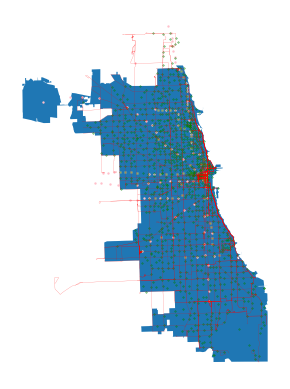

In [43]:
fig, ax = plt.subplots()

chicago_city_boundaries.plot(ax=ax)
l_stations.plot(ax=ax, color="pink", markersize=0.5)
bus_routes.plot(ax=ax, color="red", linewidth=0.1)
divvy_stations.plot(ax=ax, color="green", markersize=0.1)

ax.set_axis_off()

In [19]:
CTA_LINES = ["red", "blue", "g", "o", "brn", "pnk", "p", "y"]
cta_lines_dict = {}
for cta_line in CTA_LINES:
    cta_lines_dict[cta_line] = l_stops[l_stops[cta_line]]

In [11]:
l_stops.set_index("station_name")

,location_state,location_zip,station_descriptive_name,blue,y,location_address,location_city,brn,direction_id,map_id,g,stop_name,p,ada,pnk,stop_id,red,o,geometry
station_name,,,,,,,,,,,,,,,,,,,
18th,,,18th (Pink Line),False,False,,,False,W,40830,False,18th (54th/Cermak-bound),False,True,True,30162,False,False,POINT (-87.66915 41.85791)
18th,,,18th (Pink Line),False,False,,,False,E,40830,False,18th (Loop-bound),False,True,True,30161,False,False,POINT (-87.66915 41.85791)
35th/Archer,,,35th/Archer (Orange Line),False,False,,,False,N,40120,False,35th/Archer (Loop-bound),False,True,False,30022,False,True,POINT (-87.68062 41.82935)
35th/Archer,,,35th/Archer (Orange Line),False,False,,,False,S,40120,False,35th/Archer (Midway-bound),False,True,False,30023,False,True,POINT (-87.68062 41.82935)
35th-Bronzeville-IIT,,,35th-Bronzeville-IIT (Green Line),False,False,,,False,N,41120,True,35-Bronzeville-IIT (Harlem-bound),False,True,False,30213,False,False,POINT (-87.62583 41.83168)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Western,,,Western (Pink Line),False,False,,,False,E,40740,False,Western (Loop-bound),False,True,True,30143,False,False,POINT (-87.68513 41.85422)
Wilson,,,Wilson (Red & Purple lines),False,False,,,False,S,40540,False,Wilson (Loop-bound),True,True,False,30385,False,False,POINT (-87.65759 41.96427)
Wilson,,,Wilson (Red & Purple lines),False,False,,,False,N,40540,False,Wilson (Linden-bound),True,True,False,30386,False,False,POINT (-87.65759 41.96427)


To do: create NetworkX graph from Chicago L and bus stops representing possible transfers and cost of transfer. 

#### Bikeshare model


Based on [Geoff Boeing - OSMNx Examples](https://github.com/gboeing/osmnx-examples/blob/main/notebooks/13-isolines-isochrones.ipynb): 

In [26]:
# configure the place, network type, trip times, and travel speed
place = {"city": "Chicago", "state": "Illinois"}
network_type = "bike"
trip_times = [5, 10, 15, 20, 25]  # in minutes
travel_speed = 16  # walking speed in km/hour

In [27]:
G = ox.graph.graph_from_place(place, network_type=network_type)

#### LA Metro


In [ ]:
# read in metro 
la_metro_stations = gpd.read_file("./data/230711_All_MetroRail_Stations.zip")
la_metro_a_stations = gpd.read_file("./data/230711_All_A-Line_Stations_Post_RC.zip")

<Axes: >

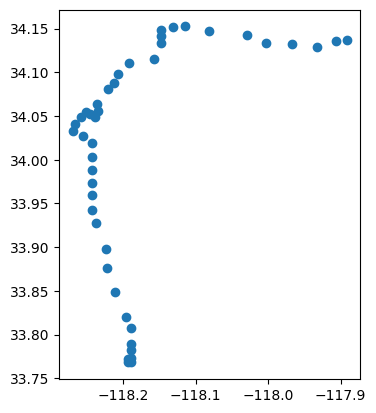

In [17]:
la_metro_a_stations.plot()

#### New York MTA data

<Axes: >

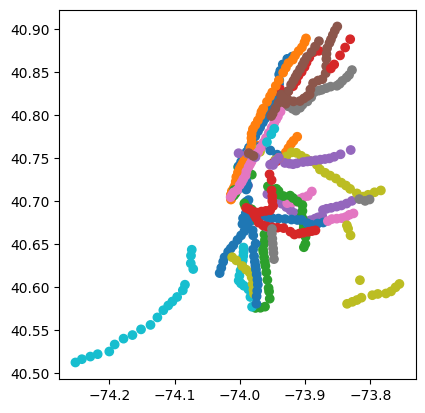

In [18]:
subway_stations = gpd.read_file("./data/MTA Subway Stations_20260520.zip")
subway_stations.plot(column="line")